# Før du går i gang
**Vigtigt:** Lav først din egen kopi af denne notebook.

Vælg:
**File → Save a copy in Drive**

Du skal herefter arbejde i kopien i dit eget Google Drive.

Du behøver ikke bruge GitHub eller Git.

---
# Upload af datafiler

Hvis du skal arbejde med en datafil, f.eks. en `.txt`-fil, kan du uploade den direkte til din **Colab-session**.

1. Klik på **Filer** i menuen til venstre.
2. Klik på **Upload**-ikonet (Upload til sessionslager)
3. Vælg datafilen på din computer.
4. Filen vil nu kunne ses under **Files** og kan bruges i Python.
---

In [7]:
!pip install contextily
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
import contextily as ctx
from scipy.interpolate import RegularGridInterpolator
from math import sqrt
from numpy import zeros, set_printoptions, genfromtxt, stack, savetxt
import numpy as np
import os


!pip install -q pyproj
# !wget -q https://raw.githubusercontent.com/holgerlindholm/DTU12821_Site-investigations_F2026/main/dk_sdfe_dnn.tif
# !wget -q https://raw.githubusercontent.com/holgerlindholm/DTU12821_Site-investigations_F2026/main/dk_sdfe_gvr2016.tif
!wget -q https://raw.githubusercontent.com/holgerlindholm/DTU12821_Site-investigations_F2026/main/ArcticDEM_Sisimiut.tif

# pyproj_dir = pyproj.datadir.get_data_dir()
# os.replace("dk_sdfe_dnn.tif", f"{pyproj_dir}/dk_sdfe_dvr90.tif")
# os.replace("dk_sdfe_gvr2016.tif", f"{pyproj_dir}/dk_sdfe_gvr2016.tif")

# print(pyproj.datadir.get_data_dir())

from math import sqrt
from numpy import zeros, set_printoptions, genfromtxt, stack, savetxt

set_printoptions(precision=3, suppress=True)  # print altid 3 decimaler når arrays udskrives.

print("✅ Workspace setup complete! You are ready to start.")


✅ Workspace setup complete! You are ready to start.


In [8]:
CSV_FILE = r"/content/rtksofmikahoj2.txt" # <--- Insæt .txt/.csv fil med jeres RTK højder (i GR96 / UTM zone 22N)
BUFFER_M = 500                 # <-- Antal meter kortet skal vises fra RTK sporet
CONTOUR_INTERVAL_M = 5         # <-- Hvor tæt skal konturlinjerne lægges

# NEDENSTÅENDE SKAL IKKE ÆNDRES
# Arcitc DEM er en satellitbaseret elevationsmodel over hele Arktis målt i WGS 84 / NSIDC Sea Ice Polar Stereographic North
# Oplæsnignen på Arctic DEM er maximal 2 meter
DEM_FILE = r"/content/ArcticDEM_Sisimiut.tif"
DST_CRS = "EPSG:3182"          # CRS kode for GR96 / UTM zone 22N
BASEMAP_SOURCE = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"
BASEMAP_ATTRIBUTION = "Imagery (c) Google"
BASEMAP_ZOOM = "auto"

## Indlæsning af data

Kør følgende blok for at definere funktioner til at indlæse og behandle data.

* **`load_gnss_points()`** indlæser Easting, Northing og Elevation fra RTK-målingernes CSV-fil.
* **`compute_bounds()`** beregner det område, som GNSS-punkterne dækker, inklusive en valgt buffer.
* **`load_dem_subset()`** indlæser den relevante del af DEM'en og reprojicerer den til det ønskede koordinatsystem (I vores tilfælde er det UTM22N GR96)

In [13]:
# ============================================================
# Indlæs data
# ============================================================

def load_gnss_points(csv_file):
    """
    Indlæser Easting, Northing og Elevation fra RTK-målingernes CSV-fil.

    Kolonnerne i den oprindelige fil læses med:
        usecols=(2, 1, 3)

    Det betyder:
        kolonne 2 -> Easting
        kolonne 1 -> Northing
        kolonne 3 -> Elevation

    Parameters
    ----------
    csv_file : str
        Filsti til CSV-filen med GNSS-målingerne.

    Returns
    -------
    easting : numpy array
        Easting-koordinater for GNSS-punkterne.

    northing : numpy array
        Northing-koordinater for GNSS-punkterne.

    elevation : numpy array
        Målte højder for GNSS-punkterne.
    """

    data = np.genfromtxt(
        csv_file,
        skip_header=1,
        delimiter=",",
        usecols=(2, 1, 3)
    )

    easting = data[:, 0]
    northing = data[:, 1]
    elevation = data[:, 2]

    return easting, northing, elevation


def compute_bounds(easting, northing, buffer_m):
    """
    Beregner et rektangulært område omkring GNSS-punkterne.

    Området bestemmes ud fra den mindste og største Easting- og
    Northing-koordinat. Der tilføjes samtidig en buffer på begge
    sider, så DEM'en også dækker et område omkring målepunkterne.

    Parameters
    ----------
    easting : numpy array
        Easting-koordinater for GNSS-punkterne.

    northing : numpy array
        Northing-koordinater for GNSS-punkterne.

    buffer_m : float
        Ekstra afstand i meter omkring GNSS-punkterne.

    Returns
    -------
    tuple
        (xmin, ymin, xmax, ymax), som beskriver det ønskede område.
    """

    return (
        easting.min() - buffer_m,
        northing.min() - buffer_m,
        easting.max() + buffer_m,
        northing.max() + buffer_m,
    )


def load_dem_subset(dem_file, dst_crs, bounds):
    """
    Indlæser og reprojicerer den del af DEM'en, der dækker området
    omkring GNSS-punkterne.

    I stedet for at reprojicere hele DEM-filen reprojiceres kun det
    nødvendige område. Det gør processen hurtigere og reducerer
    hukommelsesforbruget, især hvis DEM-filen er stor.

    DEM'en bliver reprojiceret til det koordinatsystem, der angives
    med `dst_crs`.

    Parameters
    ----------
    dem_file : str
        Filsti til DEM-filen, typisk en GeoTIFF.

    dst_crs : CRS
        Det koordinatsystem, som DEM'en skal reprojiceres til.

    bounds : tuple
        Området, som DEM'en skal dække:
        (xmin, ymin, xmax, ymax).

    Returns
    -------
    dem : 2D numpy array
        Den reprojicerede DEM-højdematrix.

    x : 1D numpy array
        Easting-koordinater for DEM'ens søjler.

    y : 1D numpy array
        Northing-koordinater for DEM'ens rækker.
    """

    xmin, ymin, xmax, ymax = bounds

    with rasterio.open(dem_file) as src:
        src_crs = src.crs

        # Beregn DEM'ens opløsning efter reprojektion.
        #
        # Vi bruger den oprindelige DEM's opløsning som udgangspunkt,
        # så vi undgår unødvendig op- eller nedsampling.
        full_transform, _, _ = calculate_default_transform(
            src_crs,
            dst_crs,
            src.width,
            src.height,
            *src.bounds
        )

        xres = full_transform.a
        yres = -full_transform.e

        # Beregn hvor mange pixels der er nødvendige for at dække
        # det ønskede område.
        width = max(
            1,
            int(np.ceil((xmax - xmin) / xres))
        )

        height = max(
            1,
            int(np.ceil((ymax - ymin) / yres))
        )

        # Opret transformationen for det nye DEM-område.
        #
        # xmin = venstre kant
        # ymax = øverste kant
        # xres = pixelstørrelse i Easting-retningen
        # yres = pixelstørrelse i Northing-retningen
        dst_transform = from_origin(
            xmin,
            ymax,
            xres,
            yres
        )

        # Opret en tom matrix til den reprojicerede DEM.
        #
        # NaN bruges til områder, hvor der ikke findes gyldige
        # DEM-værdier.
        dem = np.full(
            (height, width),
            np.nan,
            dtype=np.float32
        )

        # Reprojicer DEM'en til det nye koordinatsystem og område.
        #
        # Bilinear interpolation bruges til at beregne højdeværdier
        # mellem de oprindelige DEM-pixels.
        reproject(
            source=rasterio.band(src, 1),
            destination=dem,
            src_transform=src.transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear,
        )

    # Beregn Easting-koordinaten for hver DEM-søjle.
    x = (
        np.arange(width) * dst_transform.a
        + dst_transform.c
    )

    # Beregn Northing-koordinaten for hver DEM-række.
    y = (
        np.arange(height) * dst_transform.e
        + dst_transform.f
    )

    # Sørg for, at Northing-koordinaterne går fra syd til nord.
    #
    # Rasterdata gemmes normalt med den øverste række først,
    # hvilket betyder, at y-koordinaterne ofte går fra høj til lav.
    # RegularGridInterpolator kræver stigende koordinater.
    if y[0] > y[-1]:
        y = y[::-1]
        dem = np.flipud(dem)

    return dem, x, y


# ============================================================
# DEM-interpolation
# ============================================================

def interpolate_dem_elevations(
    dem,
    x,
    y,
    easting,
    northing,
):
    """
    Finder DEM-højden ved hver af GNSS-målingernes positioner.

    DEM'en indeholder højdeværdier i et regelmæssigt grid. GNSS-
    målingerne ligger derimod normalt mellem DEM-gridets punkter.

    Derfor bruges lineær interpolation (bilinear interpolation)
    til at beregne den forventede DEM-højde præcis ved hver
    GNSS-position.

    Parameters
    ----------
    dem : 2D numpy array
        Den reprojicerede DEM med højdeværdier.

    x : 1D numpy array
        Easting-koordinater for DEM-gridets søjler.

    y : 1D numpy array
        Northing-koordinater for DEM-gridets rækker.

    easting : 1D numpy array
        Easting-koordinater for GNSS-punkterne.

    northing : 1D numpy array
        Northing-koordinater for GNSS-punkterne.

    Returns
    -------
    dem_elevation : 1D numpy array
        Interpolerede DEM-højder ved hver GNSS-position.
    """

    # Opret en interpolator ud fra DEM-gridet.
    #
    # (y, x) angives i denne rækkefølge, fordi DEM-matricen har
    # Northing som række-koordinat og Easting som søjle-koordinat.
    interpolator = RegularGridInterpolator(
        (y, x),
        dem,
        method="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    # Kombiner Northing og Easting til koordinatpar.
    #
    # Hvert punkt bliver:
    # [Northing, Easting]
    #
    # Dette matcher rækkefølgen (y, x), som interpolatoren bruger.
    points = np.column_stack(
        (northing, easting)
    )

    # Beregn DEM-højden ved hvert GNSS-punkt.
    dem_elevation = interpolator(points)

    return dem_elevation

## Plotning

Funktionen `plot_map()` laver et kort, hvor DEM'en, højdekurverne og GNSS-målepunkterne vises sammen med et baggrundskort.

* **DEM:** Vises som et transparent terrænkort.
* **Baggrundskort:** Tilføjes med `contextily`.
* **Højdekurver:** Beregnes med et fast interval og vises i meter.
* **GNSS-punkter:** Vises som røde punkter oven på DEM'en.
* **Akser:** Viser Easting og Northing i meter.

In [22]:
# ============================================================
# Plotning
# ============================================================

def plot_map(dem, x, y, easting, northing, bounds, dst_crs):
    # Hent grænserne for det område, der skal vises
    xmin, ymin, xmax, ymax = bounds

    # Opret figur og akse
    fig, ax = plt.subplots(figsize=(12, 10))

    # Vis DEM'en som et transparent terrænkort
    ax.imshow(
        dem,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="lower",
        cmap="terrain",
        alpha=0.35,
        zorder=1,
    )

    # Begræns kortets område til GNSS-punkternes område
    # inklusive den valgte buffer
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Tilføj baggrundskort
    ctx.add_basemap(
        ax,
        crs=dst_crs,
        source=BASEMAP_SOURCE,
        attribution=BASEMAP_ATTRIBUTION,
        zoom=BASEMAP_ZOOM,
        zorder=0,
    )

    # Beregn niveauerne for højdekurverne
    levels = np.arange(
        np.floor(np.nanmin(dem) / CONTOUR_INTERVAL_M)
        * CONTOUR_INTERVAL_M,
        np.ceil(np.nanmax(dem) / CONTOUR_INTERVAL_M)
        * CONTOUR_INTERVAL_M
        + CONTOUR_INTERVAL_M,
        CONTOUR_INTERVAL_M,
    )

    # Tegn højdekurver
    contours = ax.contour(
        x,
        y,
        dem,
        levels=levels,
        colors="black",
        linewidths=0.5,
        zorder=2,
    )

    # Skriv højden på højdekurverne
    ax.clabel(
        contours,
        inline=True,
        fontsize=8,
        fmt="%d m"
    )

    # Plot GNSS-målepunkterne
    ax.scatter(
        easting,
        northing,
        s=40,
        c="red",
        edgecolors="black",
        linewidths=0.7,
        label="GNSS-punkter",
        zorder=5,
    )

    # Navngiv akser og titel
    ax.set_xlabel("Easting [m]")
    ax.set_ylabel("Northing [m]")
    ax.set_title(
        "DEM og GNSS-punkter — GR96 / UTM Zone 22N (EPSG:3182) Ellipsoidehøjder"
    )

    # Sørg for samme målestok på begge akser
    ax.set_aspect("equal")

    # Vis signaturforklaring
    ax.legend()

    # Tilpas layout og vis figuren
    plt.tight_layout()
    plt.show()

## Kørsel af funktionerne

Kør følgende blok for at gennemføre hele arbejdsgangen fra indlæsning af GNSS-data til det færdige kort.

- `load_gnss_points()` indlæser Easting, Northing og Elevation fra CSV-filen.
- `compute_bounds()` beregner kortets område omkring GNSS-punkterne med den valgte buffer.
- `load_dem_subset()` indlæser og reprojicerer den relevante del af DEM'en til det ønskede koordinatsystem.
- `plot_map()` viser DEM'en, højdekurverne, baggrundskortet og GNSS-målepunkterne.


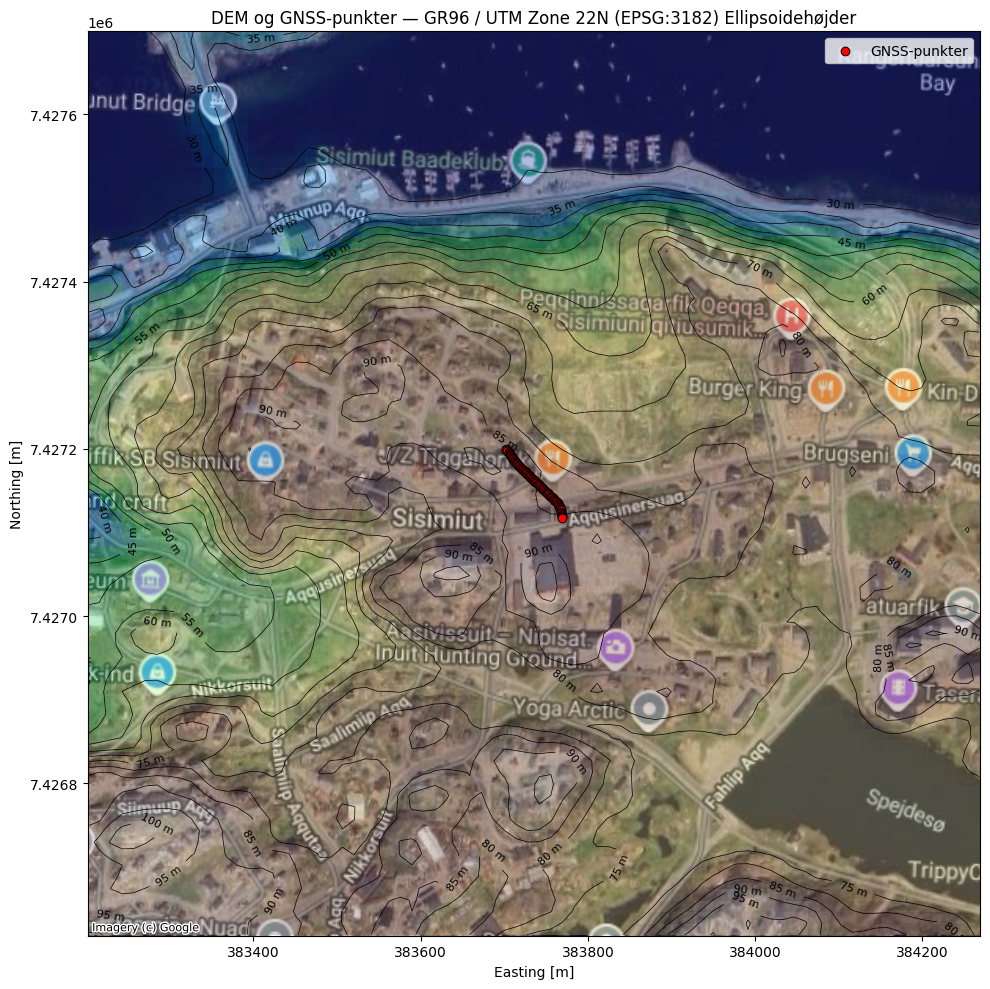

In [23]:
easting, northing, elevation = load_gnss_points(CSV_FILE)
bounds = compute_bounds(easting, northing, BUFFER_M)
dem, x, y = load_dem_subset(DEM_FILE, DST_CRS, bounds)

plot_map(dem, x, y, easting, northing, bounds, DST_CRS)

Opgave: Kommentér på kortet:
P



## Beregning af afstand langs RTK-profilen

Vi vil nu beregne afstanden langs RTK-profilen. For hvert målepunkt
ønsker vi at finde den samlede afstand fra profilens startpunkt.

Afstanden mellem to punkter i et Easting/Northing-koordinatsystem kan
beregnes ved hjælp af:

$$
l = \sqrt{(E-E_0)^2 + (N-N_0)^2}
$$

Hvor:

- $E, N$ er koordinaterne for det aktuelle punkt.
- $E_0, N_0$ er koordinaterne for startpunktet.
- $l$ er den vandrette afstand mellem punkterne.

### Opgave

Beregn først afstanden mellem hvert par af efterfølgende GNSS-punkter.
Brug derefter de enkelte afstande til at beregne den **kumulative afstand
fra profilens startpunkt**.

Udfyld de manglende dele i koden nedenfor:

hint: Jeres observationer ligger gemt i easting, northing, elevation. E0 kan eg. findes ved easting[0]

In [19]:
E0 = "?"
N0 = "?"
# Afstand mellem hvert par af efterfølgende punkter
afstande = "?"


## Plot af højdeprofil

Denne kode skal **ikke ændres**. Den bruges til at:

1. Beregne DEM-højden ved hvert GNSS-målepunkt.
2. Plot de målte GNSS-højder og DEM-højder langs RTK-profilen.
3. Vise afstanden fra startpunktet på x-aksen og højden på y-aksen.

### Refleksionsspørgsmål

Undersøg højdeprofilen og overvej følgende:

1. **Hvilken opløsning har DEM'en, og hvordan adskiller den sig fra RTK-profilens målepunkter?**
   Hvad betyder forskellen i opløsning for, hvor detaljeret terrænet kan beskrives?

2. **Hvor godt stemmer DEM-højderne overens med RTK-målingerne?**
   Hvor ser I de største afvigelser, og hvad kan være årsagerne til disse?

3. **Hvilke højder ville I have størst tillid til – RTK eller DEM – og hvorfor?**
   Overvej RTK-målingernes præcision og DEM'ens rolle som en mere overordnet beskrivelse af terrænet. Hvordan kan DEM'en stadig være nyttig som kontekst?


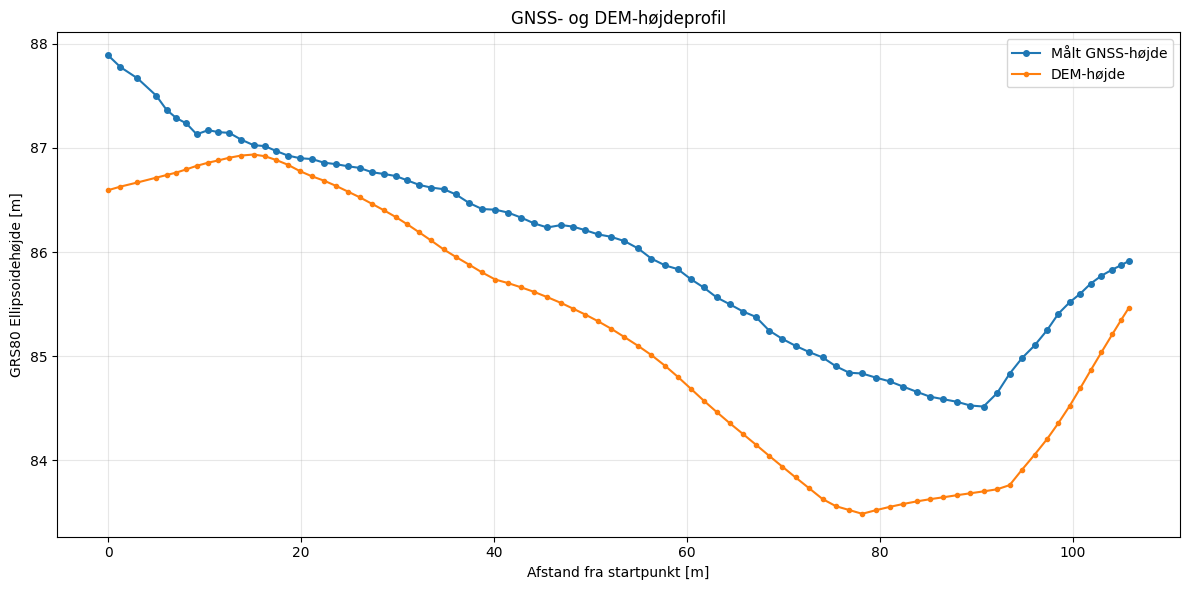

In [24]:
# Beregn DEM-højden ved hvert GNSS-målepunkt
dem_elevation = interpolate_dem_elevations(
    dem,
    x,
    y,
    easting,
    northing,
)

# -------------------------------------------------------
# Plot højdeprofil
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

# Plot de målte GNSS-højder
ax.plot(
    afstande,
    elevation,
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="Målt GNSS-højde",
)

# Plot DEM-højderne
ax.plot(
    afstande,
    dem_elevation,
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="DEM-højde",
)

# Navngiv akser og titel
ax.set_xlabel("Afstand fra startpunkt [m]")
ax.set_ylabel("GRS80 Ellipsoidehsøjde [m]")
ax.set_title("GNSS- og DEM-højdeprofil")

# Tilføj gitter og signaturforklaring
ax.grid(True, alpha=0.3)
ax.legend()

# Tilpas layout og vis figuren
plt.tight_layout()
plt.show()